In [1]:
import pandas as pd

shopping_data = pd.read_csv("data/processed/shopping_cleaned.csv")

In [2]:
shopping_data.head(10)

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card
5,25.0,Female,Jacket,31.595005,Washington,M,Mauve,Fall,Present,Standard,No,4,Credit Card
6,39.0,Female,Shorts,32.374104,Colorado,M,Fuchsia,Summer,Missing,Standard,No,3,Credit Card
7,45.0,Female,Jacket,35.548978,Florida,M,Brown,Winter,Missing,Standard,No,10,Credit Card
8,23.0,Male,Backpack,34.437918,Texas,M,Brown,Winter,Missing,Standard,No,2,Credit Card
9,27.0,Female,Handbag,29.430620,Virginia,XL,Black,Summer,Missing,Standard,No,2,Credit Card


In [3]:
shopping_data['Item Purchased'].unique()

<StringArray>
[     'Leggings',    'Sunglasses',         'Dress',        'Shorts',
        'Jacket',      'Backpack',       'Handbag',       'Pajamas',
       'Sweater', 'Running Shoes',        'Hoodie',        'Gloves',
         'Socks',         'Scarf',       'T-shirt',          'Belt',
         'Boots',         'Jeans']
Length: 18, dtype: str

In [4]:
import matplotlib.pyplot as plt

In [5]:
shopping_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3158 non-null   float64
 1   Gender                 3158 non-null   str    
 2   Item Purchased         3158 non-null   str    
 3   Purchase Amount (USD)  3158 non-null   float64
 4   Location               3158 non-null   str    
 5   Size                   3158 non-null   str    
 6   Color                  3158 non-null   str    
 7   Season                 3158 non-null   str    
 8   Review Rating          3158 non-null   str    
 9   Shipping Type          3158 non-null   str    
 10  Promo Code Used        3158 non-null   str    
 11  Previous Purchases     3158 non-null   int64  
 12  Payment Method         3158 non-null   str    
dtypes: float64(2), int64(1), str(10)
memory usage: 320.9 KB


In [6]:
shopping_data.describe()

,Age,Purchase Amount (USD),Previous Purchases
count,3158.000000,3158.000000,3158.000000
mean,34.185244,38.812750,5.860988
std,10.578195,11.525595,5.844408
min,18.000000,11.946095,0.000000
25%,26.000000,29.419108,1.000000
50%,33.000000,37.126663,4.000000
75%,41.000000,48.974363,9.000000
max,73.000000,68.327455,20.000000


In [7]:
shopping_data.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()

Promo Code Used
No     30.155751
Yes    50.067480
Name: Purchase Amount (USD), dtype: float64

In [8]:
shopping_data.groupby(['Season', 'Color']).size().reset_index(name='Count')

,Season,Color,Count
0,Fall,Aubergine,83
1,Fall,Baby blue,16
2,Fall,Black,84
3,Fall,Brick red,88
4,Fall,Brown,97
...,...,...,...
63,Winter,Periwinkle,8
64,Winter,Ruby Red,107
65,Winter,Terra cotta,101
66,Winter,Turquoise,16


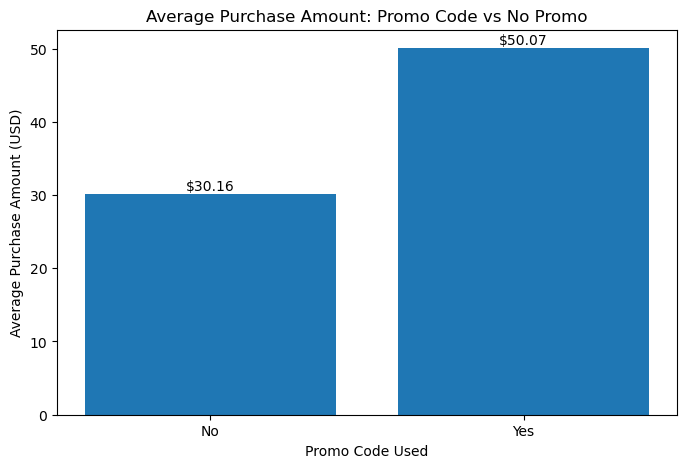

In [9]:
promo_spending = shopping_data.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()

plt.figure(figsize=(8,5))
bars = plt.bar(
    promo_spending.index.astype(str),
    promo_spending.values
)
plt.title('Average Purchase Amount: Promo Code vs No Promo')
plt.xlabel('Promo Code Used')
plt.ylabel('Average Purchase Amount (USD)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'${height:.2f}',
        ha='center'
    )

plt.show()

In [10]:
season_revenue = shopping_data.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

print(season_revenue)

Season
Winter    40168.104540
Fall      33953.962697
Summer    29642.915700
Spring    18805.682195
Name: Purchase Amount (USD), dtype: float64


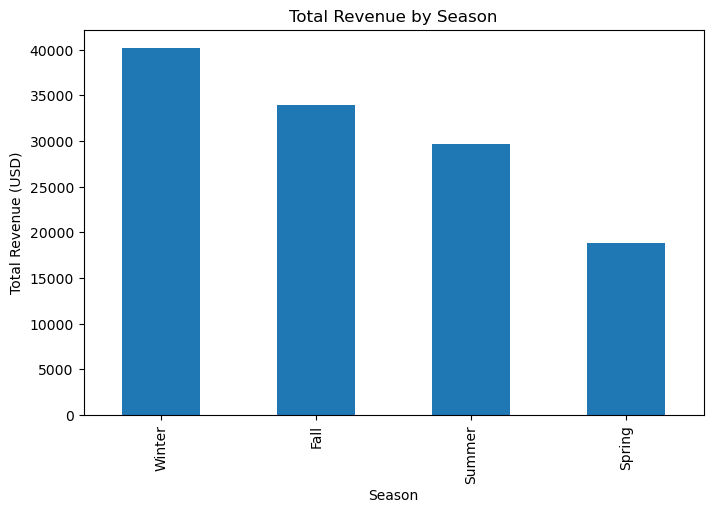

In [11]:
season_revenue.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Revenue by Season'
)

plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.show()

In [27]:
top_states = (
    shopping_data.groupby('Location')['Purchase Amount (USD)']
    .mean()
    .sort_values(ascending=False)
    .head(25)
)

print(top_states)

Location
Indiana           44.015818
Iowa              41.671086
Hawaii            41.414186
Massachusetts     41.376207
Missouri          41.100242
Florida           41.067119
Oregon            40.693077
South Carolina    40.656722
Arkansas          39.885000
West Virginia     39.857050
Idaho             39.746202
New York          39.667587
Nebraska          39.402254
Nevada            39.383811
Mississippi       39.358984
Louisiana         39.297439
Wisconsin         39.234511
North Carolina    39.213291
Maryland          39.201186
New Mexico        39.193420
New Hampshire     39.055198
Utah              38.990109
Washington        38.952245
Maine             38.944262
Delaware          38.923192
Name: Purchase Amount (USD), dtype: float64


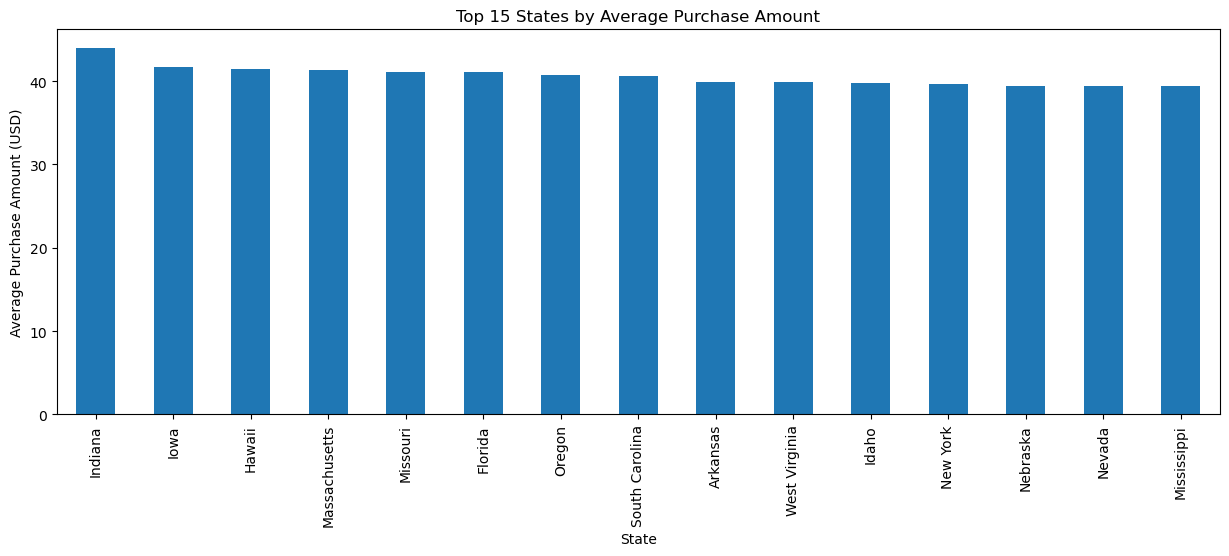

In [21]:
top_states.plot(
    kind='bar',
    figsize=(15,5),
    title='Top 15 States by Average Purchase Amount'
)

plt.xlabel('State')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

In [13]:
color_season = pd.pivot_table(
    shopping_data,
    index='Season',
    columns='Color',
    values='Gender',
    aggfunc='count',
    fill_value=0
)

print(color_season)

Color   Aubergine  Baby blue  Black  Brick red  Brown  Burnt orange  Fuchsia  \
Season                                                                         
Fall           83         16     84         88     97            93        3   
Spring          2         69      5          7      5             4       45   
Summer         13         84      9         12      3             5       78   
Winter        111         21    124        110     89           112       18   

Color   Lavender  Lemon yellow  Mauve  Muted mustard yellow  Pale peach  \
Season                                                                    
Fall          13             9     86                    84           9   
Spring        55            47      5                     8          52   
Summer       102            98      7                    13          81   
Winter         6            13     95                    87          15   

Color   Periwinkle  Ruby Red  Terra cotta  Turquoise  White  
Season

In [ ]:
bins = [18, 25, 35, 50, 65, 100]
labels = ['18-25', '26-35', '36-50', '51-65', '65+']

shopping_data['Age Group'] = pd.cut(shopping_data['Age'], bins=bins, labels=labels)

age_spending = shopping_data.groupby('Age Group')['Purchase Amount (USD)'].mean()

print(age_spending)

Age Group
18-25    38.683711
26-35    38.625054
36-50    38.869152
51-65    39.443982
65+      41.498458
Name: Purchase Amount (USD), dtype: float64
